In [1]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
import random


def random_flip(image):
    if random.choice([True, False]):
        image = np.fliplr(image)
    return image


def add_salt_and_pepper_noise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy_image = image.copy()
    total_pixels = image.size

    num_salt = int(salt_prob * total_pixels)
    salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_image[salt_coords[0], salt_coords[1]] = 255

    num_pepper = int(pepper_prob * total_pixels)
    pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0

    return noisy_image


def normalize_depth(depth_img):
    depth_min = np.min(depth_img)
    depth_max = np.max(depth_img)
    normalized_depth = (depth_img - depth_min) / (depth_max - depth_min) * 255
    return normalized_depth.astype(np.uint8)


def enhance_depth_contrast(depth_img, gamma=2.0):
    normalized_depth = normalize_depth(depth_img)
    enhanced_depth = np.power(normalized_depth / 255.0, gamma) * 255
    return np.clip(enhanced_depth, 0, 255).astype(np.uint8)


def resize_w_enhanced_depth(image, target_size=(256, 384), gamma=1.2):
    enhanced_depth_image = enhance_depth_contrast(image, gamma)
    resized_image = cv.resize(
        enhanced_depth_image, target_size, interpolation=cv.INTER_LINEAR
    )
    return resized_image

In [3]:
total = {}
AUGMENT = False
for batch in os.listdir("batches"):
    batch_path = os.path.join("batches", batch)
    if os.path.isdir(batch_path):
        df = []
        for item in os.listdir(batch_path):
            item_path = os.path.join(batch_path, item)
            if os.path.isdir(item_path):
                for img in os.listdir(item_path):
                    img_path = os.path.join(item_path, img)
                    if os.path.isfile(img_path) and "depth" in img_path:
                        image = Image.open(img_path)
                        image = np.array(image)
                        image[image <= 1] = 0
                        df.append(image)
                        if AUGMENT:
                            for _ in range(4):
                                df.append(random_flip(image))

                            for deg in range(random.randint(a=1, b=5)):
                                peppered = add_salt_and_pepper_noise(
                                    image, salt_prob=deg * 0.02, pepper_prob=deg * 0.02
                                )
                                df.append(peppered)

                                for _ in range(4):
                                    df.append(random_flip(peppered))

                            df.append(add_salt_and_pepper_noise(image))

            total[item_path] = {"data": df}

In [4]:
reference = 1280 * 480
for key, df in total.items():
    pixel_sizes = [x.shape[0] * x.shape[1] for x in df["data"]]
    total[key]["pixel_sizes"] = np.array(pixel_sizes)
    std_depth = [np.std(x) for x in df["data"]]
    total[key]["std_depth"] = np.array(std_depth)
    pixel_ratio = np.array([size / reference for size in pixel_sizes])
    total[key]["pixel_ratio"] = pixel_ratio
    adjusted_df = [resize_w_enhanced_depth(x) for x in df["data"]]
    total[key]["data"] = adjusted_df
    approx_volume = [np.sum(x) for x in df["data"]]
    total[key]["volume_proxy"] = np.array(approx_volume)
    aspect_ratios = [x.shape[1] / x.shape[0] for x in df["data"]]
    total[key]["aspect_ratio"] = np.array(aspect_ratios)

In [5]:
import pandas as pd
weights = pd.read_csv("weight.csv")
weights, weights.shape

(   pig_num     weight
 0        1  15.218280
 1        3  17.328257
 2        4  17.019110
 3        5  16.761245
 4        6  28.424365
 5        8  15.987649,
 (6, 2))

In [6]:
for (key, df), w in zip(total.items(), weights['weight'].to_list()):
    total[key]["weight"] = w

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.optim as optim


class DepthImageDataset(Dataset):
    def __init__(self, data_dict):
        self.images = []
        self.features = []
        self.weights = []

        for key in data_dict.keys():
            images = data_dict[key]["data"]
            feature_keys = [k for k in data_dict[key].keys() if k not in ['data', 'weight']]

            # Collect per-image feature vectors
            per_image_features = np.stack([data_dict[key][k] for k in feature_keys], axis=1)

            # Same weight for all images in this group
            weights = [data_dict[key]["weight"]] * len(images)

            self.images.extend(images)
            self.features.extend(per_image_features)
            self.weights.extend(weights)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx], dtype=torch.float32)
        feature = torch.tensor(self.features[idx], dtype=torch.float32)
        weight = torch.tensor(self.weights[idx], dtype=torch.float32)
        return image, feature, weight

In [8]:
# Change the number of keys to fit what you have. In this example, 2 pigs will be used to train, and the last 2 will be used for validation.
train_val_ratio = 0.7 # 10 pigs = 8 train, 2 val
all_keys = list(total.keys())
random.shuffle(all_keys)

num_total = len(all_keys)
num_train = int(num_total * train_val_ratio)

train_keys = all_keys[:num_train]
val_keys = all_keys[num_train:]

train_data_dict = {key: total[key] for key in train_keys}
val_data_dict = {key: total[key] for key in val_keys}

In [9]:
{k:v for k,v in zip(train_keys, weights['weight'][:num_train])}, {k:v for k,v in zip(val_keys, weights['weight'][num_train:])}

({'batches\\1\\pig_E': 15.21828,
  'batches\\1\\pig_F': 17.3282571,
  'batches\\1\\pig_B': 17.0191098,
  'batches\\1\\pig_D': 16.7612445},
 {'batches\\1\\pig_C': 28.4243652, 'batches\\1\\pig_A': 15.9876486})

In [10]:
train_dataset = DepthImageDataset(train_data_dict)
val_dataset = DepthImageDataset(val_data_dict)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [11]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split

X = []
y = []

for batch in train_dataloader:
    features = batch[1].detach().cpu().numpy() 
    weights = batch[-1].detach().cpu().numpy()

    X.extend(features.reshape(features.shape[0], -1))
    y.extend(weights.flatten())

X = np.array(X)
y = np.array(y)

In [12]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

lgbm = LGBMRegressor()
lgbm.fit(X_train, y_train)

preds = lgbm.predict(X_val)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1011
[LightGBM] [Info] Number of data points in the train set: 3724, number of used features: 4
[LightGBM] [Info] Start training from score 19.630550


C:\Users\Tawan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [13]:
rmse = np.sqrt(np.mean((preds - y_val) ** 2))
print(f"RMSE: {rmse:.3f}")

RMSE: 5.624


In [14]:
class CNN(nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels=1,
    ):
        super(CNN, self).__init__()
        # You can not change the conv1(in_channels) and fc4 (out_features).
        # Do not change kernel_size, stride, padding.
        # You can change the out channels but make sure to adjust for the consequent layer.
        # Example: conv1(out_channels) is 16 so conv2(in_channels) must be 16 or conv1(out_channels) = conv2(in_channels).

        # Image Encoder
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=hidden_channels,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.conv2 = nn.Conv2d(
            in_channels=hidden_channels,
            out_channels=hidden_channels * 2,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.conv3 = nn.Conv2d(
            in_channels=hidden_channels * 2,
            out_channels=hidden_channels * 4,
            kernel_size=3,
            stride=1,
            padding=1,
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)
        self.fc1 = nn.Linear(264 * hidden_channels, hidden_channels * 4)
        self.fc2 = nn.Linear(hidden_channels * 4, hidden_channels * 2)
        self.fc3 = nn.Linear(hidden_channels * 2 + 1, out_channels)

    def forward(self, x, x_pred):
        
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))

        x = x.reshape(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        if x_pred.dim() == 1:
            x_pred = x_pred.unsqueeze(1)
        x = torch.cat([x, x_pred], dim=1)
        x = torch.relu(self.fc3(x))
        return x

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN(in_channels = 1, hidden_channels = 32)
model = model.to(device=device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.002)

In [22]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

Total parameters: 1,182,466
Trainable parameters: 1,182,466
Epoch [1/10], Training Loss: 43.41035229539218, Evaluation Loss: 8.821985277411056
Epoch [2/10], Training Loss: 27.836768489994416, Evaluation Loss: 22.861334343479104
Epoch [3/10], Training Loss: 30.100103286847677, Evaluation Loss: 3.3315714385411512
Epoch [4/10], Training Loss: 27.732172966003418, Evaluation Loss: 2.1787121246938836
Epoch [5/10], Training Loss: 27.401433193520322, Evaluation Loss: 10.887772076750455
Epoch [6/10], Training Loss: 27.561098346971487, Evaluation Loss: 6.2008493632486426
Epoch [7/10], Training Loss: 28.001977025646053, Evaluation Loss: 8.652891916771457
Epoch [8/10], Training Loss: 27.93708471729331, Evaluation Loss: 11.823963766228664
Epoch [9/10], Training Loss: 27.356751533403788, Evaluation Loss: 14.19350038815851
Epoch [10/10], Training Loss: 27.522376981500077, Evaluation Loss: 11.874910694279082


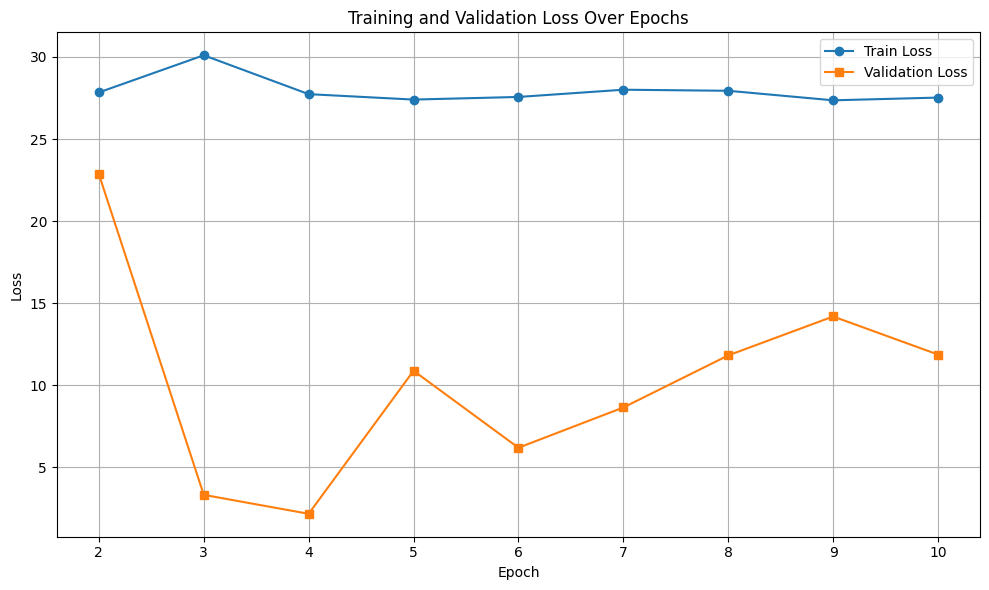

In [23]:
# If you want to add or remove features you must also change the size of this.
num_epochs = 10
total_losses = []

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

for epoch in range(num_epochs):
    model.train()

    losses = {"train": 0.0, "val": 0.0}

    for images, features, w in train_dataloader:
        images = images.to(device=device)
        features = features.cpu().numpy()
        
        if images.shape[1] != 1:  # Check if it's not grayscale
            images = images[:, 0, :, :].unsqueeze(1)

        x_preds = lgbm.predict(np.array(features))
        x_preds = torch.tensor(x_preds, dtype=torch.float32).to(images.device)
        w = w.to(device=device)
        optimizer.zero_grad()

        outputs = model(images, x_preds)

        loss = criterion(outputs.squeeze(), w)

        loss.backward()
        optimizer.step()

        losses["train"] += loss.item()

    model.eval()

    for images, features, w in val_dataloader:
        images = images.to(device=device)
        features = features.cpu().numpy()

        if images.shape[1] != 1:
            images = images[:, 0, :, :].unsqueeze(1)
        
        w = w.to(device=device)
        x_preds = lgbm.predict(np.array(features))
        x_preds = torch.tensor(x_preds, dtype=torch.float32).to(images.device)

        outputs = model(images, x_preds)

        loss = criterion(outputs.squeeze(), w)
        losses["val"] += loss.item()

    print(
        f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {losses['train'] / len(train_dataloader)}, Evaluation Loss: {losses['val'] / len(val_dataloader)}"
    )

    total_losses.append(losses)

train_losses = [loss["train"] / len(train_dataloader) for loss in total_losses]
val_losses = [loss["val"] / len(val_dataloader) for loss in total_losses]

warmup = 1
plt.figure(figsize=(10, 6))
plt.plot(
    range(warmup + 1, num_epochs + 1), train_losses[warmup:], label="Train Loss", marker="o"
)
plt.plot(
    range(warmup + 1, num_epochs + 1),
    val_losses[warmup:],
    label="Validation Loss",
    marker="s",
)
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import time
torch.save(model.state_dict(), f"pt//model_{time.time()}.pt")

In [25]:
model.eval()
device = "cuda"

val_rmse = 0
num_batches = 0

with torch.no_grad():
    for images, features, labels in val_dataloader:
        images = images.to(device=device)
        features = features.cpu().numpy()

        if images.shape[1] != 1:
            images = images[:, 0, :, :].unsqueeze(1)
        
        x_preds = lgbm.predict(np.array(features))
        x_preds = torch.tensor(x_preds, dtype=torch.float32).to(images.device)

        outputs = model(images, x_preds)

        mse = nn.MSELoss()(outputs, labels.unsqueeze(-1).to(images.device))
        rmse = torch.sqrt(mse)
        val_rmse += rmse.item()
        num_batches += images.shape[0]

avg_val_rmse = val_rmse / num_batches

print(f"Validation RMSE: {avg_val_rmse}")

Validation RMSE: 0.10794043264438197


In [27]:
mse = nn.MSELoss()(x_preds, labels.unsqueeze(-1).to(images.device))
rmse = torch.sqrt(mse)
rmse

tensor(3.7886, device='cuda:0')

In [28]:
df = pd.DataFrame({
    "y_pred": x_preds.cpu().numpy(),
    "y": labels.cpu().numpy(),
    'diff': labels.cpu().numpy() - x_preds.cpu().numpy()
})
df

,y_pred,y,diff
0,20.294090,17.01911,-3.274981
1,20.127327,17.01911,-3.108217
2,18.846874,17.01911,-1.827765
3,20.168581,17.01911,-3.149471
4,19.673441,17.01911,-2.654331
5,18.981094,17.01911,-1.961985
6,19.477617,15.21828,-4.259337
7,19.432667,15.21828,-4.214387
8,18.985132,17.01911,-1.966022
9,20.002892,15.21828,-4.784612


In [32]:
mse = nn.MSELoss()(outputs.flatten(), labels.unsqueeze(-1).to(images.device))
rmse = torch.sqrt(mse)
rmse

tensor(3.5245, device='cuda:0')

In [30]:
df = pd.DataFrame({
    "y_pred": outputs.flatten().cpu().numpy(),
    "y": labels.cpu().numpy(),
    'diff': labels.cpu().numpy() - outputs.flatten().cpu().numpy()
})
df

,y_pred,y,diff
0,19.552834,17.01911,-2.533724
1,19.525263,17.01911,-2.506153
2,19.313572,17.01911,-2.294462
3,19.532084,17.01911,-2.512974
4,19.450224,17.01911,-2.431114
5,19.335762,17.01911,-2.316652
6,19.417850,15.21828,-4.199571
7,19.410419,15.21828,-4.192140
8,19.336430,17.01911,-2.317320
9,19.504692,15.21828,-4.286412
